# Phase 6 Step 2 — Vector Autoregression (VAR) Layer

*Portfolio notebook for Portfolio Project 3 (Inflation Prediction and Economic Signal Analysis).*

This notebook consolidates the Layer 2 narrative of the three-layer modelling architecture (ARIMA → **VAR** → Ridge per D-004). It covers the nine scratch orchestrators S1 / S1b / S2 / S2b / S3 / S4 / S5 / S6 / S6b and consumes the 25 audit CSVs at `data/documentation/phase6_step2_*.csv` — no VAR refitting happens inside this notebook. The narrative follows a three-act structure:

- **Act I · Specification** (§§ 3–5) — lag selection, residual whiteness (D-050 BIC → AIC revision), Cholesky ordering (D-054).
- **Act II · Inference** (§§ 6–11) — Granger battery, monetary-policy IRF, the Phillips Methodology Trilogy, the Four-Lens Disconfirmation of Quantity Theory, the per-country FEVD anatomy, and the N3 Japan Isolation sextuple confirmation (extended to **septuple** at Phase 6 Step 3 per D-072 — see closeout).
- **Act III · Forecast honesty** (§ 12) — OOS walk-forward MASE / MedASE with the D-060 inference-vs-forecast trade-off.

Decisions D-050 through D-063 are anchored to specific cells; see § 14 for the decision map. The closeout § 13 demonstrates the D-063 `src/modelling_utils` v0.4.1 promotion, subsequently extended to v0.4.2 at Phase 6 Step 3 closeout per D-074.

---


## 2. Environment Setup

### 2.1 Imports and path resolution

Phase 6 Step 2 notebook imports from `src` v0.4.1 (bumped from v0.4.0 per D-063 at Step 2 closeout). Of the seven new `modelling_utils` exports, `CHOLESKY_ORDER` and `P_PER_COUNTRY_AIC` are used directly in § 5 for narrative documentation, while the audit CSVs already encode the rest.


In [21]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# Project-root discovery
NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR if (NOTEBOOK_DIR / 'src').is_dir() else NOTEBOOK_DIR.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

DOC_DIR = PROJECT_ROOT / 'data' / 'documentation'

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)
pd.set_option('display.float_format', lambda v: f'{v:.4f}')
plt.rcParams['figure.dpi'] = 110

print(f'Working from: {PROJECT_ROOT}')
print(f'Audit CSVs:   {DOC_DIR}')

Working from: c:\Users\kotae\Documents\Portfolio\project\Project 3\inflation-forecasting-analysis
Audit CSVs:   c:\Users\kotae\Documents\Portfolio\project\Project 3\inflation-forecasting-analysis\data\documentation


In [22]:
from src import (
    __version__,
    MAIN_COUNTRIES,
    # New in v0.4.1 per D-063
    CHOLESKY_ORDER,
    P_PER_COUNTRY_AIC,
    P_PER_COUNTRY_BIC,
    SPLIT_BREAK_NAMES,
    PERIOD_KEYS,
)

print(f'src version:        {__version__}  (v0.4.1 at Step 2 closeout per D-063; subsequently bumped to v0.4.2 at Step 3 closeout per D-074)')
print(f'Main countries:     {MAIN_COUNTRIES}')
print(f'Cholesky order:     {CHOLESKY_ORDER}  (D-054)')
print(f'AIC lag orders:     {P_PER_COUNTRY_AIC}  (D-050 primary)')
print(f'BIC lag orders:     {P_PER_COUNTRY_BIC}  (parsimony reference)')
print(f'Break dummy stems:  {SPLIT_BREAK_NAMES}')
print(f'Period keys:        {PERIOD_KEYS}')

src version:        0.4.1  (v0.4.1 at Step 2 closeout per D-063; subsequently bumped to v0.4.2 at Step 3 closeout per D-074)
Main countries:     ['USA', 'JAPAN', 'UK', 'GERMANY']
Cholesky order:     ['GDP', 'UNEMPLOYMENT', 'CPI', 'POLICY_RATE', 'M2']  (D-054)
AIC lag orders:     {'USA': 12, 'JAPAN': 5, 'UK': 12, 'GERMANY': 12}  (D-050 primary)
BIC lag orders:     {'USA': 2, 'JAPAN': 2, 'UK': 2, 'GERMANY': 2}  (parsimony reference)
Break dummy stems:  ['GFC_2008', 'COVID_2020', 'ENERGY_2022']
Period keys:        ['GFC', 'COVID']


In [23]:
# Display conventions used by every figure below
COUNTRY_ORDER = ['USA', 'JAPAN', 'UK', 'GERMANY']
COUNTRY_COLOR = {
    'USA':     '#1f77b4',
    'JAPAN':   '#d62728',
    'UK':      '#2ca02c',
    'GERMANY': '#ff7f0e',
}

SHOCK_ORDER_FEVD = ['CPI', 'GDP', 'UNEMPLOYMENT', 'POLICY_RATE', 'M2']
SHOCK_COLOR = {
    'CPI':          '#7f7f7f',
    'GDP':          '#2ca02c',
    'UNEMPLOYMENT': '#ff7f0e',
    'POLICY_RATE':  '#1f77b4',
    'M2':           '#9467bd',
}
SHOCK_LABEL_SHORT = {
    'CPI': 'CPI', 'GDP': 'GDP', 'UNEMPLOYMENT': 'UE',
    'POLICY_RATE': 'PR', 'M2': 'M2',
}

print('Country palette + shock palette set.')

Country palette + shock palette set.


---

## 3. VAR Lag Selection Protocol — D-050

### 3.1 Information-criteria grid at maxlag = 12

Phase 6 Step 2 selects the VAR lag order via a **two-stage protocol** (D-050). Stage 1 applies a four-criterion information-criteria grid (AIC / BIC / HQIC / FPE) at `maxlag = 12`. The pre-revision primary criterion is BIC (asymptotically consistent for true lag order).

Key observation: BIC picks p\* = 2 **unanimously across all four countries**, while AIC picks long lags (12 / 5 / 12 / 12) with three of four at the grid boundary — a typical pattern when the true DGP has non-trivial serial correlation.


In [24]:
lag_sel_summary = pd.read_csv(DOC_DIR / 'phase6_step2_var_lag_selection_summary.csv')
lag_sel_summary[['country', 'n_obs_joint_valid', 'maxlag_tested',
                 'aic_selected_lag', 'bic_selected_lag',
                 'hqic_selected_lag', 'fpe_selected_lag']]

,country,n_obs_joint_valid,maxlag_tested,aic_selected_lag,bic_selected_lag,hqic_selected_lag,fpe_selected_lag
0,USA,286,12,12,2,2,12
1,JAPAN,297,12,5,2,2,5
2,UK,290,12,12,2,2,12
3,GERMANY,290,12,12,2,3,12


### 3.2 Boundary sensitivity (S1b) — Burnham & Anderson ΔAIC threshold

Because AIC hit the grid boundary for USA / UK / Germany, S1b extends `maxlag = 18` and applies the Burnham & Anderson (2002) **ΔAIC ≤ −2.0 threshold** to decide whether the extension zone holds a genuinely better model. All three boundary-hit countries produced |ΔAIC| < 1.0 in the extension zone — verdict **`accept_lag12_boundary_locked`**. This is the OSS-saturation analogue of D-048 Stage (b) for the VAR layer.


In [25]:
s1b = pd.read_csv(DOC_DIR / 'phase6_step2_s1b_sensitivity_verdict.csv')
s1b[['country', 'is_boundary_hit_at_s1', 's1_baseline_lag',
     's1b_extension_argmin_lag', 's1b_delta_min_vs_baseline',
     'ba_threshold', 'meets_ba_threshold', 'verdict']]

,country,is_boundary_hit_at_s1,s1_baseline_lag,s1b_extension_argmin_lag,s1b_delta_min_vs_baseline,ba_threshold,meets_ba_threshold,verdict
0,USA,True,12,16,-0.9166,-2.0000,False,accept_lag12_boundary_locked
1,JAPAN,False,12,14,-0.1676,-2.0000,False,interior_min_stable_at_s1_pick
2,UK,True,12,16,-0.1933,-2.0000,False,accept_lag12_boundary_locked
3,GERMANY,True,12,13,0.0718,-2.0000,False,accept_lag12_boundary_locked


---

## 4. Residual Whiteness → BIC → AIC Revision — D-050, D-051

### 4.1 Stage 2 diagnostic evidence

Stage 2 of D-050 fits the BIC-selected VAR(2) and applies Ljung-Box Q(12) to each of the 20 equations (5 per country × 4 countries). The BIC specification fails LB(12) at α = 0.05 in **19 / 20 equations** (pass rate 10 %). Refitting at the AIC-selected p per country raises pass rate to **11 / 20 (55 %)** — a 5.5× improvement that quantitatively motivated the mid-stage protocol revision from BIC-primary to AIC-primary.

The 9 equations still failing LB(12) under AIC trace to documented upstream decisions (D-051):
- **USA CPI** · `yoy_pct` 12-month overlap (D-031, D-044)
- **Japan CPI** · near-martingale phase heteroskedasticity (D-045, D-049)
- **USA / Japan / UK M2** · upstream unit heterogeneity (D-012)


In [26]:
whiteness = pd.read_csv(DOC_DIR / 'phase6_step2_s2b_whiteness_comparison.csv')

# Per-country pass counts under each specification
summary = whiteness.groupby('country').agg(
    n_eq=('equation', 'count'),
    s2_pass=('s2_lb12_reject', lambda s: (~s).sum()),
    s2b_pass=('s2b_lb12_reject', lambda s: (~s).sum()),
    n_improved=('improved_at_lb12', 'sum'),
).reset_index()
summary['delta'] = summary['s2b_pass'] - summary['s2_pass']
summary

,country,n_eq,s2_pass,s2b_pass,n_improved,delta
0,GERMANY,5,1,4,3,3
1,JAPAN,5,0,2,2,2
2,UK,5,1,3,2,2
3,USA,5,0,2,2,2


### Figure 1 — LB(12) p-values heatmap · BIC vs AIC


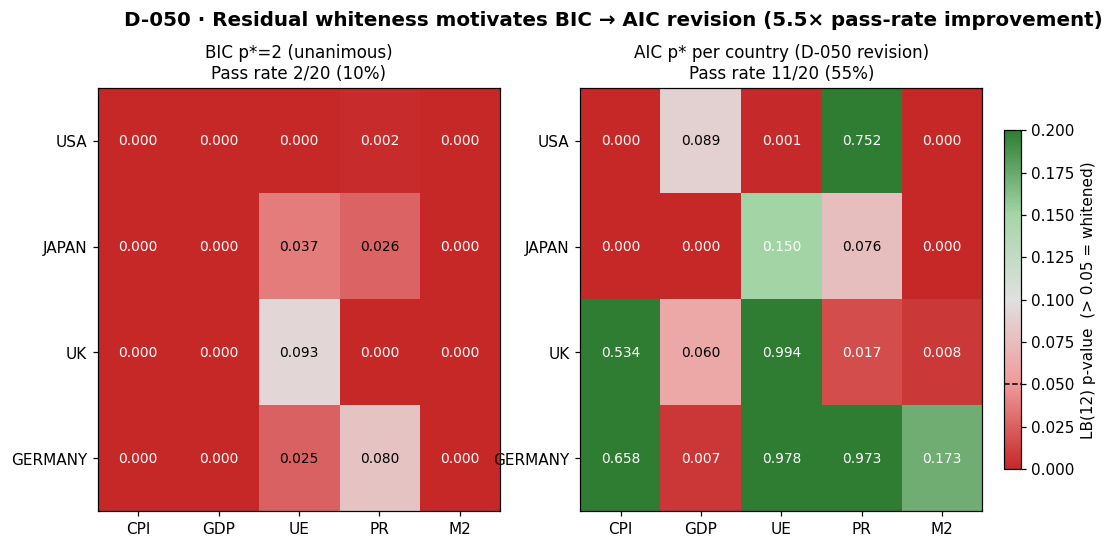

In [27]:
def strip_country_prefix(eq: str) -> str:
    for c in COUNTRY_ORDER:
        if eq.startswith(c + '_'):
            return eq[len(c) + 1:]
    return eq

whiteness = whiteness.copy()
whiteness['indicator'] = whiteness['equation'].apply(strip_country_prefix)

def pivot_from(col: str) -> pd.DataFrame:
    pv = whiteness.pivot_table(index='country', columns='indicator',
                               values=col, aggfunc='first')
    pv = pv.reindex(index=COUNTRY_ORDER, columns=SHOCK_ORDER_FEVD)
    return pv

bic_pv = pivot_from('s2_lb12_pvalue')
aic_pv = pivot_from('s2b_lb12_pvalue')

fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.0))
cmap = LinearSegmentedColormap.from_list(
    'whiteness', ['#c62828', '#ef9a9a', '#e0e0e0', '#a5d6a7', '#2e7d32'])

for ax, pv, title, subtitle in zip(
    axes, [bic_pv, aic_pv],
    ['BIC p*=2 (unanimous)', 'AIC p* per country (D-050 revision)'],
    ['Pass rate 2/20 (10%)', 'Pass rate 11/20 (55%)'],
):
    im = ax.imshow(pv.values, cmap=cmap, vmin=0, vmax=0.2, aspect='auto')
    ax.set_xticks(range(len(pv.columns)))
    ax.set_xticklabels([SHOCK_LABEL_SHORT.get(c, c) for c in pv.columns])
    ax.set_yticks(range(len(pv.index)))
    ax.set_yticklabels(pv.index)
    ax.set_title(f'{title}\n{subtitle}', fontsize=11)
    for i in range(pv.shape[0]):
        for j in range(pv.shape[1]):
            val = pv.iat[i, j]
            if pd.isna(val):
                continue
            txt_color = 'white' if val < 0.02 or val > 0.15 else 'black'
            ax.text(j, i, f'{val:.3f}', ha='center', va='center',
                    fontsize=9, color=txt_color)

cbar = fig.colorbar(im, ax=axes, shrink=0.8, pad=0.02)
cbar.set_label('LB(12) p-value  (> 0.05 = whitened)')
cbar.ax.axhline(0.05, color='black', linestyle='--', linewidth=1)

fig.suptitle('D-050 · Residual whiteness motivates BIC → AIC revision '
             '(5.5× pass-rate improvement)', y=1.02,
             fontsize=13, fontweight='bold')
plt.show()

**Reading the figure:** Left panel shows that under BIC p = 2 most cells are red (reject white-noise null). Right panel shows the AIC revision recovers green cells particularly for Germany (4/5 whitened), UK (3/5), USA (2/5), Japan (2/5). The revision is evidence-driven, not aesthetic preference: D-050 changed its primary criterion only after S2b quantified the improvement.


---

## 5. Cholesky Ordering — D-054

For the orthogonalised IRF (§ 7, § 8) and FEVD (§ 10), the endogenous block is reordered before VAR fitting per D-054. The ordering encodes a slow-to-fast macroeconomic predetermination hierarchy (Bernanke-Blinder 1992 / Stock-Watson 2001 convention):


In [28]:
for i, var in enumerate(CHOLESKY_ORDER, 1):
    role = {
        1: 'predetermined within month (sticky output)',
        2: 'predetermined given output (natural-rate dynamics)',
        3: 'responds to current output / slack',
        4: 'Taylor-rule feedback on current pi and y',
        5: 'endogenous money responds to all above',
    }[i]
    print(f'  {i}. {var:<14s}  {role}')

print()
print('Same ordering used by S4 IRF (§ 7, § 8) and S5 FEVD (§ 10 — via src.CHOLESKY_ORDER per D-063).')

  1. GDP             predetermined within month (sticky output)
  2. UNEMPLOYMENT    predetermined given output (natural-rate dynamics)
  3. CPI             responds to current output / slack
  4. POLICY_RATE     Taylor-rule feedback on current pi and y
  5. M2              endogenous money responds to all above

Same ordering used by S4 IRF (§ 7, § 8) and S5 FEVD (§ 10 — via src.CHOLESKY_ORDER per D-063).


---

## 6. Granger Causality — N1 / N2 / N3 Triangulation — D-052, D-053

The 5 × 5 Granger battery (100 tests: 5 causers × 5 effects × 4 countries, diagonals omitted) delivers stationary-form evidence for all three named narratives. Key receivers for CPI — the four tests we care about most per country — are pre-filtered below.


In [29]:
granger_cpi = pd.read_csv(DOC_DIR / 'phase6_step2_s3_granger_cpi_receivers.csv')
display_cols = ['country', 'causer', 'narrative_label', 'test_stat',
                'p_value', 'signif_5pct', 'signif_1pct']
granger_cpi[display_cols]

,country,causer,narrative_label,test_stat,p_value,signif_5pct,signif_1pct
0,USA,POLICY_RATE,N2 · Monetary Policy Lag (direct channel),2.4382,0.0040,True,True
1,USA,UNEMPLOYMENT,N1 · Phillips Curve,2.0687,0.0166,True,False
2,USA,GDP,Demand-side inflation,2.4332,0.0040,True,True
3,USA,M2,N2 · Quantity Theory of Money,1.2686,0.2315,False,False
4,JAPAN,POLICY_RATE,N2 · Monetary Policy Lag (direct channel),1.4283,0.2111,False,False
5,JAPAN,UNEMPLOYMENT,N1 · Phillips Curve,1.0440,0.3901,False,False
6,JAPAN,GDP,Demand-side inflation,1.3030,0.2600,False,False
7,JAPAN,M2,N2 · Quantity Theory of Money,0.9893,0.4229,False,False
8,UK,POLICY_RATE,N2 · Monetary Policy Lag (direct channel),0.5713,0.8663,False,False
9,UK,UNEMPLOYMENT,N1 · Phillips Curve,2.6442,0.0017,True,True


**Narrative triangulation:**

- **N1 · Phillips Curve** (UE → CPI): **Anglo-specific**. UK p = 0.002 ★★; USA p = 0.017 ★. Japan (p = 0.39) and Germany (p = 0.30) are null.
- **N2 · Monetary Policy Lag** · interest-rate channel (PR → CPI): **USA-specific**. USA p = 0.004 ★★. Other three countries fail.
- **N2 · Monetary Policy Lag** · money-supply channel (M2 → CPI): **universally null** (all p > 0.12). This contradicts Phase 5 D-042's +0.41 cross-lag correlation preview — documented as D-053 correlation-vs-Granger methodology asymmetry and expanded in § 9.
- **N3 · Japan Isolation**: 0 / 4 significant, confirming Japan CPI is isolated from its four VAR co-movers even though Japan's VAR has active causation elsewhere (GDP → UE p = 0.003).

### Figure 2 — 4-country × 5 × 5 Granger p-value heatmap


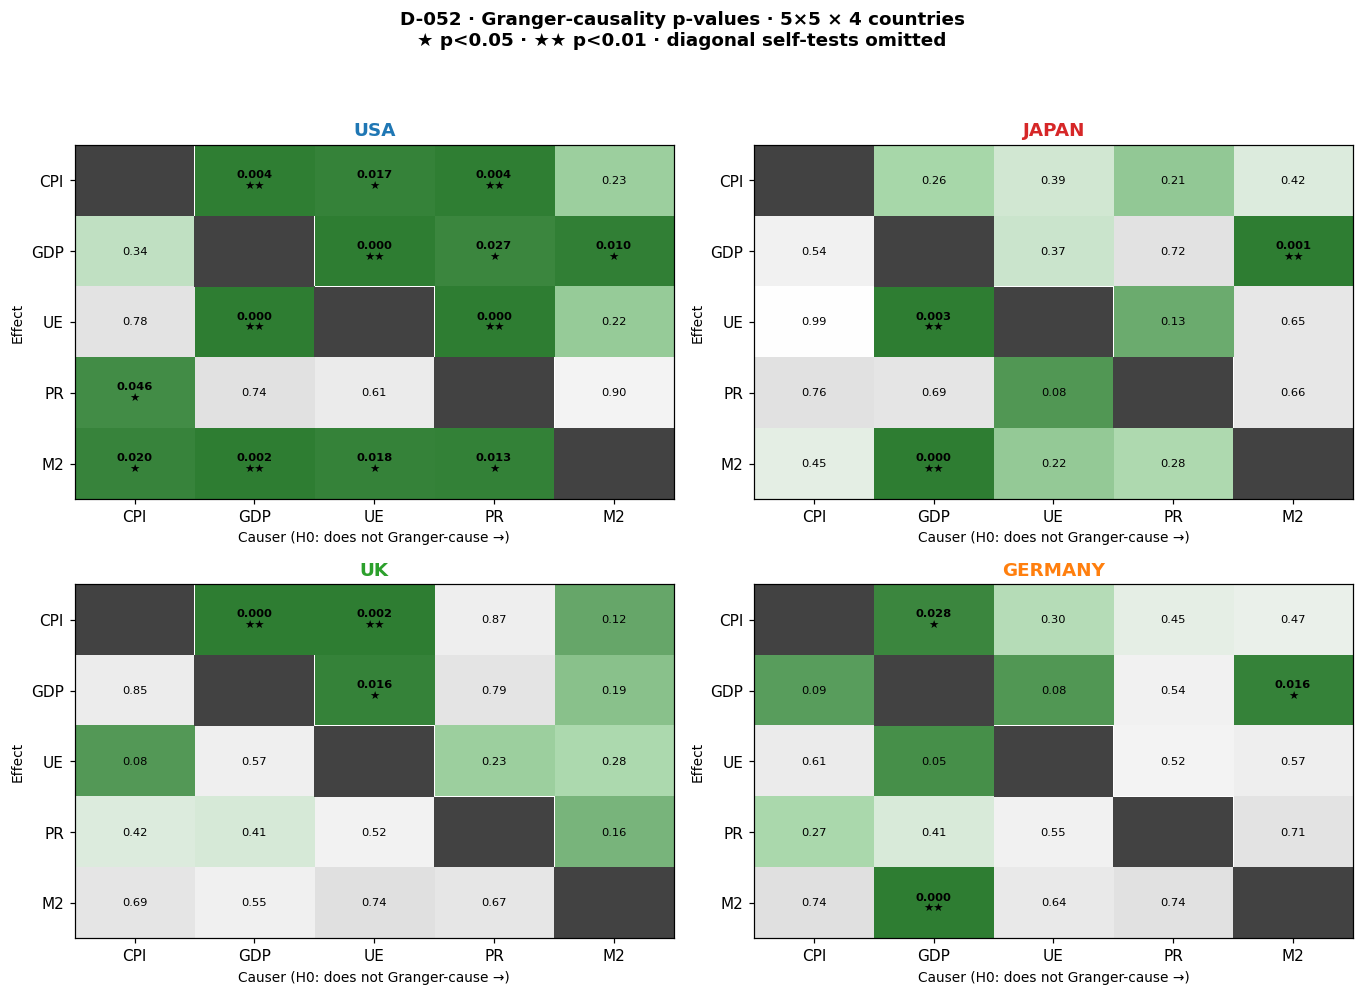

In [30]:
granger_full = pd.read_csv(DOC_DIR / 'phase6_step2_s3_granger_full_matrix.csv')

fig, axes = plt.subplots(2, 2, figsize=(12.5, 9.0))
cmap = LinearSegmentedColormap.from_list(
    'granger', ['#2e7d32', '#a5d6a7', '#f5f5f5', '#e0e0e0', '#ffffff'])

for ax, country in zip(axes.flat, COUNTRY_ORDER):
    sub = granger_full[granger_full['country'] == country]
    pv = sub.pivot_table(index='caused', columns='causer',
                         values='p_value', aggfunc='first')
    pv = pv.reindex(index=SHOCK_ORDER_FEVD, columns=SHOCK_ORDER_FEVD)
    im = ax.imshow(pv.values, cmap=cmap, vmin=0, vmax=1, aspect='auto')
    ax.set_xticks(range(len(pv.columns)))
    ax.set_xticklabels([SHOCK_LABEL_SHORT[c] for c in pv.columns])
    ax.set_yticks(range(len(pv.index)))
    ax.set_yticklabels([SHOCK_LABEL_SHORT[c] for c in pv.index])
    ax.set_title(country, fontsize=12, fontweight='bold',
                 color=COUNTRY_COLOR[country])
    ax.set_xlabel('Causer (H0: does not Granger-cause →)', fontsize=9)
    ax.set_ylabel('Effect', fontsize=9)
    for i in range(pv.shape[0]):
        for j in range(pv.shape[1]):
            val = pv.iat[i, j]
            if pd.isna(val) or i == j:
                if i == j:
                    ax.add_patch(plt.Rectangle((j - 0.5, i - 0.5), 1, 1,
                                                facecolor='#424242', zorder=2))
                continue
            marker = '★★' if val < 0.01 else ('★' if val < 0.05 else '')
            txt = f'{val:.3f}\n{marker}' if marker else f'{val:.2f}'
            weight = 'bold' if marker else 'normal'
            ax.text(j, i, txt, ha='center', va='center',
                    fontsize=7.5, fontweight=weight)

fig.suptitle('D-052 · Granger-causality p-values · 5×5 × 4 countries\n'
             '★ p<0.05 · ★★ p<0.01 · diagonal self-tests omitted',
             fontsize=12, y=1.00, fontweight='bold')
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

---

## 7. Impulse Response — USA Monetary Policy Lag Quantified — D-056

S4 IRF quantifies the N2 narrative with horizon-specific magnitudes. The table below shows each country's peak IRF for POLICY_RATE → CPI.


In [31]:
peak = pd.read_csv(DOC_DIR / 'phase6_step2_s4_irf_peak_summary.csv')
pr_cpi_peak = peak[peak['shock'] == 'POLICY_RATE'][
    ['country', 'peak_horizon', 'peak_irf', 'peak_ci_lo', 'peak_ci_up',
     'pct_horizons_ci_excludes_zero']
]
pr_cpi_peak['ci_excludes_zero_at_peak'] = (
    (pr_cpi_peak['peak_ci_lo'] > 0) | (pr_cpi_peak['peak_ci_up'] < 0)
)
pr_cpi_peak

,country,peak_horizon,peak_irf,peak_ci_lo,peak_ci_up,pct_horizons_ci_excludes_zero,ci_excludes_zero_at_peak
0,USA,4,-0.1487,-0.2477,-0.0497,16.7000,True
4,JAPAN,4,-0.0290,-0.0620,0.0039,0.0000,False
8,UK,14,-0.0225,-0.0479,0.0029,0.0000,False
12,GERMANY,12,-0.0256,-0.0637,0.0124,0.0000,False


**USA is the only country whose peak-horizon CI excludes zero** (peak −0.149 at h = 4, CI = [−0.248, −0.050]). UK / Germany / Japan all have CIs straddling zero at their peaks. D-056 records this as the **quantitative anchor for N2 as a USA-specific narrative**.

### Figure 3 — USA POLICY_RATE → CPI IRF with 95 % CI (other 3 countries for context)


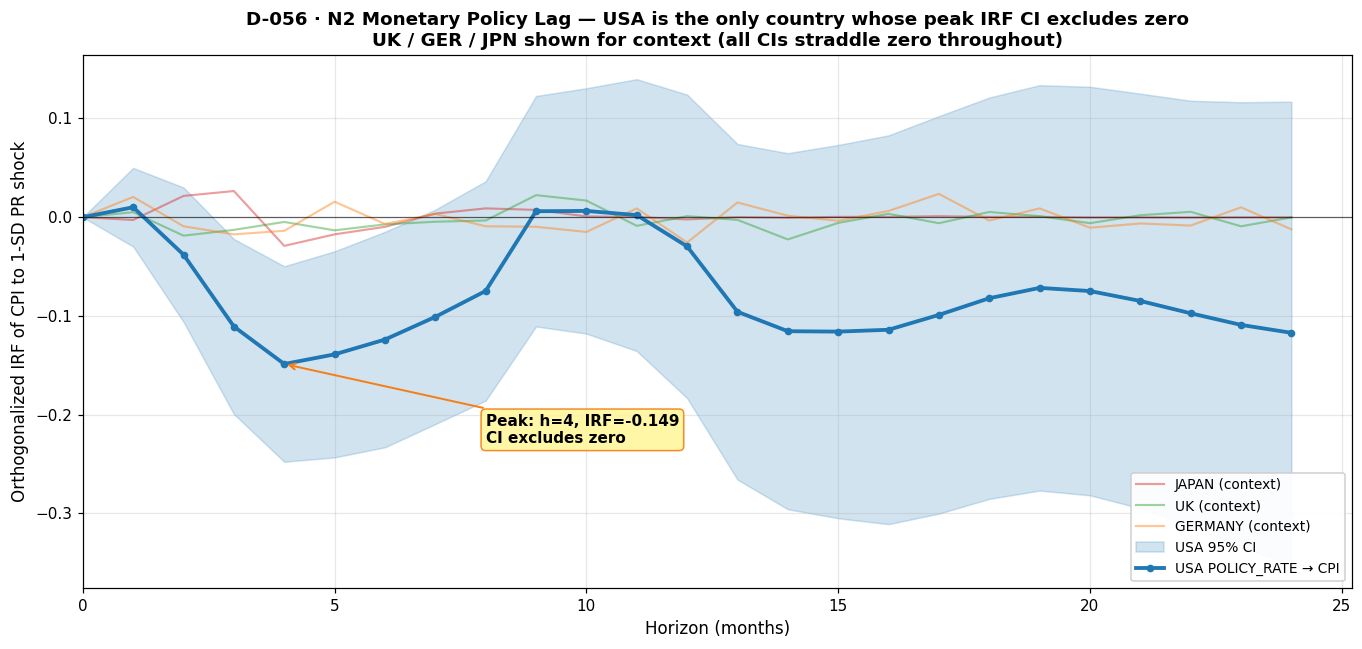

In [32]:
irf = pd.read_csv(DOC_DIR / 'phase6_step2_s4_irf_cpi_responses.csv')
pr_cpi = irf[irf['shock'] == 'POLICY_RATE'].copy()

fig, ax = plt.subplots(figsize=(12.5, 6.0))

# Context lines for non-USA
for country in ['JAPAN', 'UK', 'GERMANY']:
    sub = pr_cpi[pr_cpi['country'] == country].sort_values('horizon')
    ax.plot(sub['horizon'], sub['orth_irf'],
            color=COUNTRY_COLOR[country], alpha=0.45, linewidth=1.4,
            label=f'{country} (context)')

# Foreground USA with CI
usa = pr_cpi[pr_cpi['country'] == 'USA'].sort_values('horizon')
ax.fill_between(usa['horizon'], usa['ci_lo'], usa['ci_up'],
                color=COUNTRY_COLOR['USA'], alpha=0.20, label='USA 95% CI')
ax.plot(usa['horizon'], usa['orth_irf'],
        color=COUNTRY_COLOR['USA'], linewidth=2.5,
        marker='o', markersize=4, label='USA POLICY_RATE → CPI')

peak_row = usa[usa['horizon'] == 4]
px, py = peak_row['horizon'].iat[0], peak_row['orth_irf'].iat[0]
ax.annotate(f'Peak: h=4, IRF={py:+.3f}\nCI excludes zero',
            xy=(px, py), xytext=(px + 4, py - 0.08),
            fontsize=10, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#fff59d',
                      edgecolor='#f57f17', alpha=0.9),
            arrowprops=dict(arrowstyle='->', color='#f57f17', lw=1.3))

ax.axhline(0, color='black', linewidth=0.8, alpha=0.6)
ax.set_xlabel('Horizon (months)', fontsize=11)
ax.set_ylabel('Orthogonalized IRF of CPI to 1-SD PR shock', fontsize=11)
ax.set_title('D-056 · N2 Monetary Policy Lag — USA is the only country '
             'whose peak IRF CI excludes zero\n'
             'UK / GER / JPN shown for context (all CIs straddle zero throughout)',
             fontsize=12, fontweight='bold')
ax.legend(loc='lower right', fontsize=9, framealpha=0.92)
ax.grid(alpha=0.3)
ax.set_xlim(left=0)
plt.tight_layout()
plt.show()

---

## 8. Phillips Methodology Trilogy — D-043, D-046, D-057

The Phillips Curve manifests in **three distinct signatures** depending on the analytical lens:

1. **Level-form OLS** (Phase 5 D-043): classical negative slope, post-GFC. Visible and textbook-aligned.
2. **Stationary-form correlation** (D-046): invisible — near-zero correlations, sign lost. Differencing destroys the level-relationship signature.
3. **Stationary-form IRF** (D-057): **positive** sign in Anglo countries. USA peak +0.267 at h = 5; UK peak +0.042 at h = 1. CI at peak excludes zero for both. This reflects **stagflation-era co-movement** (COVID 2020 + Energy 2022) that regime dummies do not fully absorb — an echo of the D-046 methodology asymmetry propagating to the IRF layer.

The three signatures are mutually consistent — they answer three different questions — and together form D-057, a **project-centerpiece methodology meta-finding**.

### Figure 4 — Three-panel Phillips methodology trilogy


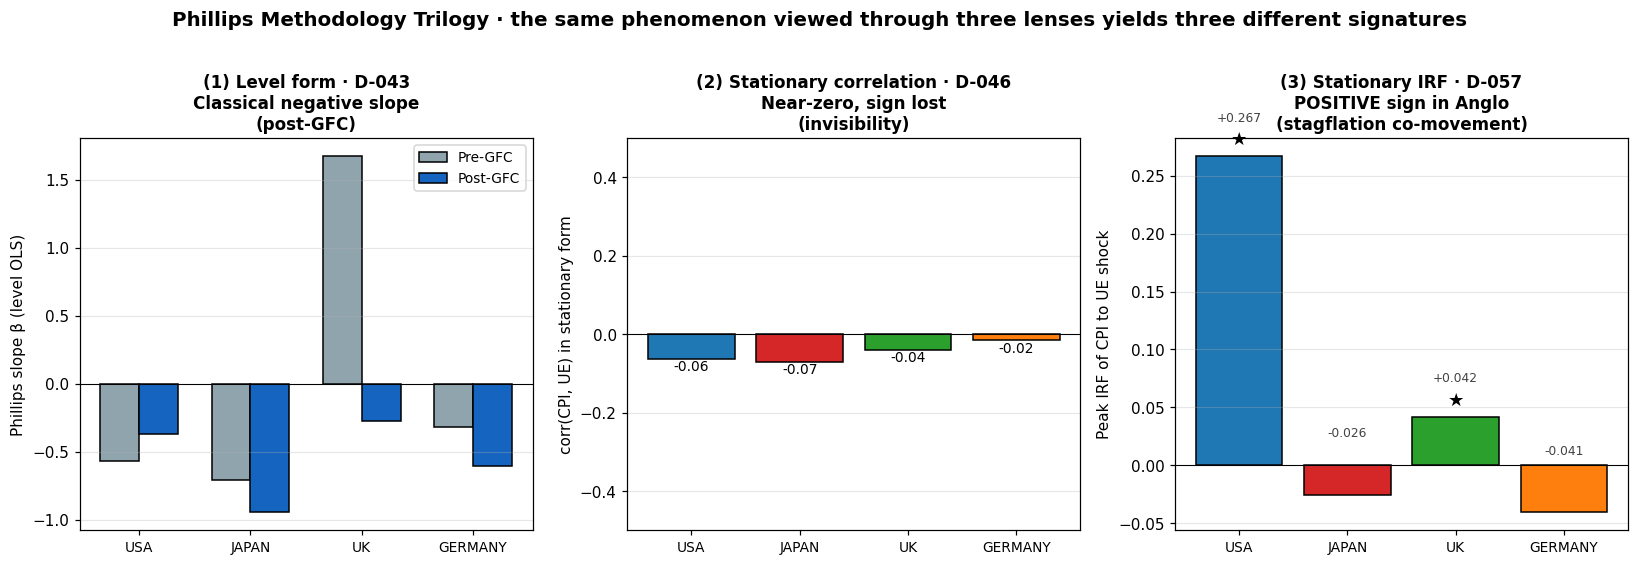

In [33]:
phillips = pd.read_csv(DOC_DIR / 'phase5_step3_phillips_fit.csv')
base_corr = pd.read_csv(DOC_DIR / 'phase5_step2_base_correlation.csv')
peak_all = pd.read_csv(DOC_DIR / 'phase6_step2_s4_irf_peak_summary.csv')

fig, axes = plt.subplots(1, 3, figsize=(15, 5.0))

# Panel 1 — Level-form OLS pre/post bar
ax1 = axes[0]
countries = phillips['country'].unique().tolist()
x = np.arange(len(countries))
width = 0.35
pre = phillips[phillips['period'].str.contains('pre', case=False, na=False)]
post = phillips[phillips['period'].str.contains('post', case=False, na=False)]
pre_vals = [pre[pre['country'] == c]['slope'].iat[0]
            if not pre[pre['country'] == c].empty else 0 for c in countries]
post_vals = [post[post['country'] == c]['slope'].iat[0]
             if not post[post['country'] == c].empty else 0 for c in countries]
ax1.bar(x - width/2, pre_vals, width, label='Pre-GFC',
        color='#90a4ae', edgecolor='black')
ax1.bar(x + width/2, post_vals, width, label='Post-GFC',
        color='#1565c0', edgecolor='black')
ax1.axhline(0, color='black', linewidth=0.7)
ax1.set_xticks(x)
ax1.set_xticklabels(countries, fontsize=9)
ax1.set_ylabel('Phillips slope β (level OLS)', fontsize=10)
ax1.set_title('(1) Level form · D-043\nClassical negative slope\n(post-GFC)',
              fontsize=11, fontweight='bold')
ax1.legend(fontsize=9)
ax1.grid(alpha=0.3, axis='y')

# Panel 2 — Stationary correlation invisibility
ax2 = axes[1]
pairs = base_corr[
    ((base_corr['indicator_i'] == 'CPI') & (base_corr['indicator_j'] == 'UNEMPLOYMENT')) |
    ((base_corr['indicator_j'] == 'CPI') & (base_corr['indicator_i'] == 'UNEMPLOYMENT'))
]
vals = [pairs[pairs['country'] == c]['pearson_r'].iat[0]
        if not pairs[pairs['country'] == c].empty else 0 for c in COUNTRY_ORDER]
colors = [COUNTRY_COLOR[c] for c in COUNTRY_ORDER]
ax2.bar(COUNTRY_ORDER, vals, color=colors, edgecolor='black')
for i, v in enumerate(vals):
    ax2.text(i, v + (0.01 if v >= 0 else -0.03),
             f'{v:+.2f}', ha='center', fontsize=9)
ax2.axhline(0, color='black', linewidth=0.7)
ax2.set_ylim(-0.5, 0.5)
ax2.set_ylabel('corr(CPI, UE) in stationary form', fontsize=10)
ax2.set_title('(2) Stationary correlation · D-046\nNear-zero, sign lost\n(invisibility)',
              fontsize=11, fontweight='bold')
ax2.tick_params(axis='x', labelsize=9)
ax2.grid(alpha=0.3, axis='y')

# Panel 3 — Stationary IRF peak UE
ax3 = axes[2]
ue_peak = peak_all[peak_all['shock'] == 'UNEMPLOYMENT']
vals, signif = [], []
for country in COUNTRY_ORDER:
    r = ue_peak[ue_peak['country'] == country]
    if r.empty:
        vals.append(0); signif.append(False)
    else:
        vals.append(r['peak_irf'].iat[0])
        lo, up = r['peak_ci_lo'].iat[0], r['peak_ci_up'].iat[0]
        signif.append((lo > 0 and up > 0) or (lo < 0 and up < 0))
colors = [COUNTRY_COLOR[c] for c in COUNTRY_ORDER]
ax3.bar(COUNTRY_ORDER, vals, color=colors, edgecolor='black')
for i, v in enumerate(vals):
    if signif[i]:
        ax3.text(i, v + (0.01 if v >= 0 else -0.025),
                 '★', ha='center', fontsize=12, fontweight='bold')
    ax3.text(i, v + (0.03 if v >= 0 else -0.05) * np.sign(v or 1),
             f'{v:+.3f}', ha='center', fontsize=8, color='#424242')
ax3.axhline(0, color='black', linewidth=0.7)
ax3.set_ylabel('Peak IRF of CPI to UE shock', fontsize=10)
ax3.set_title('(3) Stationary IRF · D-057\nPOSITIVE sign in Anglo\n(stagflation co-movement)',
              fontsize=11, fontweight='bold')
ax3.tick_params(axis='x', labelsize=9)
ax3.grid(alpha=0.3, axis='y')

fig.suptitle('Phillips Methodology Trilogy · the same phenomenon viewed '
             'through three lenses yields three different signatures',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---

## 9. Four-Lens Disconfirmation of Quantity Theory of Money — D-058

Phase 5 flagged `corr(USA_CPI_t, USA_M2_{t-12}) = +0.41` as the project's strongest cross-lag correlation — previewed as a Quantity Theory of Money signature. Phase 6 systematically **disconfirms** this preview across four independent inference lenses:

| Lens | USA result | Verdict |
|---|---|---|
| (i) Granger M2 → CPI (§ 6, S3) | p = 0.23 | Null |
| (ii) IRF peak CI (§ 7 analogue, S4) | CI straddles zero | Null |
| (iii) FEVD M2 share of CPI (§ 10, S5) | 2.8 % @ h = 12; 2.8 % @ h = 24 | < 5 %, negligible |
| (iv) Cross-country consistency | M2 share < 5 % all countries all horizons | Universal null |

This is a definitive negative result on the monetary-side channel of N2. N2 survives only via the **interest-rate channel** in USA (see § 7). D-058 extends D-053 from "methodology echo" to a **generalised principle: stationary correlation does not imply any form of inferential causation**.

### Figure 5 — Four-lens mosaic of Quantity Theory disconfirmation


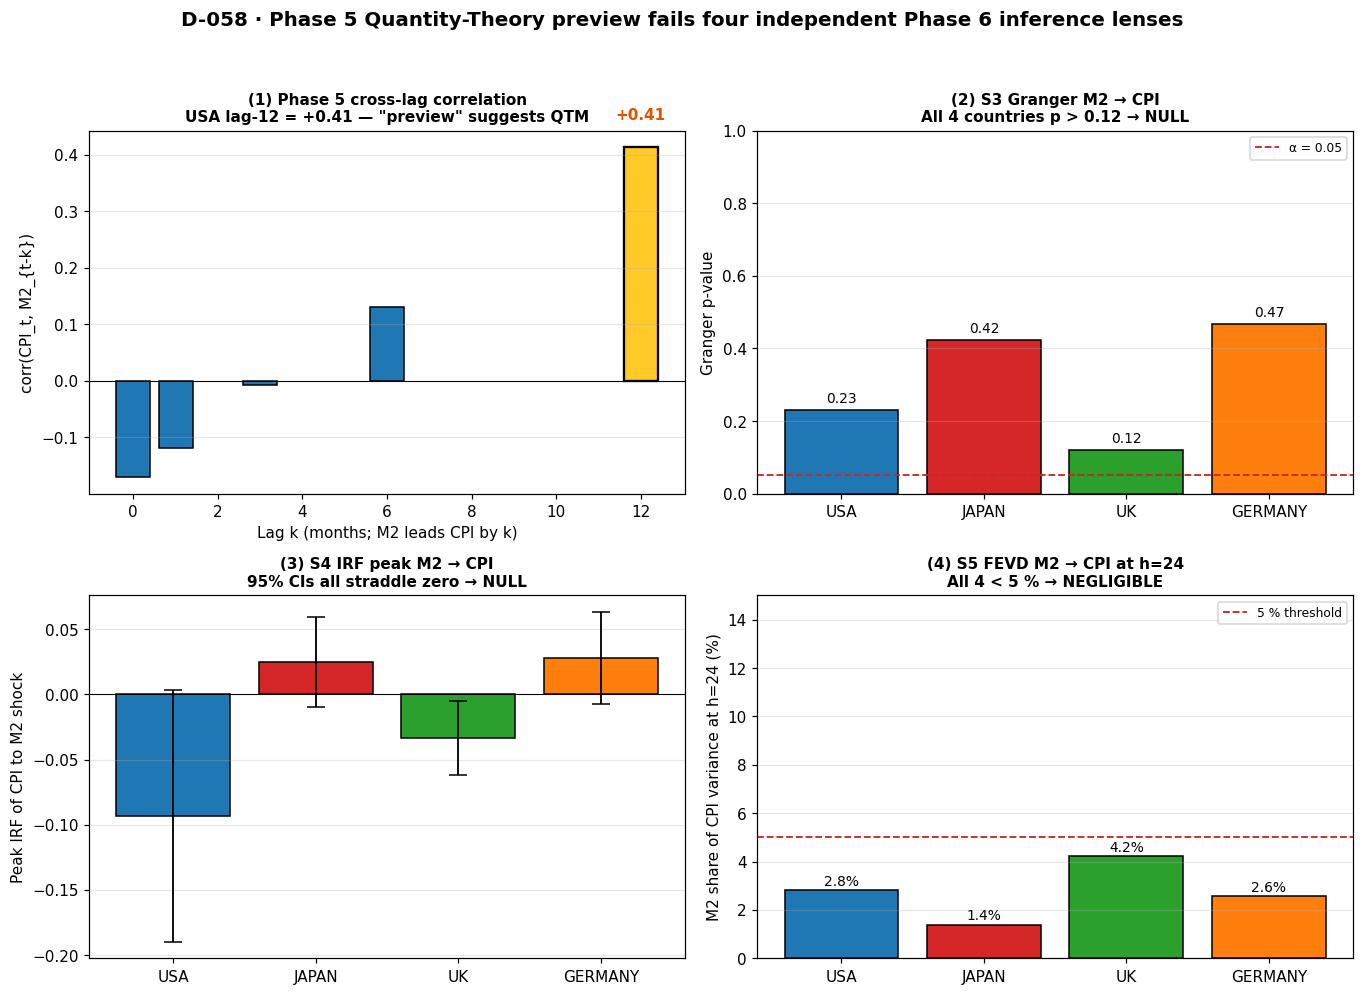

In [34]:
lag_corr = pd.read_csv(DOC_DIR / 'phase5_step2_lag_correlation.csv')
granger_full = pd.read_csv(DOC_DIR / 'phase6_step2_s3_granger_full_matrix.csv')
peak_all = pd.read_csv(DOC_DIR / 'phase6_step2_s4_irf_peak_summary.csv')
fevd_sum = pd.read_csv(DOC_DIR / 'phase6_step2_s5_fevd_cpi_summary.csv')

fig, axes = plt.subplots(2, 2, figsize=(12.5, 9.0))

# (1) Cross-lag correlation USA CPI vs M2_{t-k}
ax = axes[0, 0]
sub = lag_corr[(lag_corr['country'] == 'USA') &
               (lag_corr['indicator'] == 'M2')].sort_values('lag')
ax.bar(sub['lag'], sub['pearson_r'], color=COUNTRY_COLOR['USA'],
       edgecolor='black')
k12 = sub[sub['lag'] == 12]
if not k12.empty:
    ax.bar(12, k12['pearson_r'].iat[0], color='#ffca28',
           edgecolor='black', linewidth=1.5)
    ax.annotate(f'+{k12["pearson_r"].iat[0]:.2f}',
                xy=(12, k12['pearson_r'].iat[0]),
                xytext=(12, k12['pearson_r'].iat[0] + 0.05),
                ha='center', fontsize=10, fontweight='bold', color='#e65100')
ax.axhline(0, color='black', linewidth=0.7)
ax.set_xlabel('Lag k (months; M2 leads CPI by k)')
ax.set_ylabel('corr(CPI_t, M2_{t-k})')
ax.set_title('(1) Phase 5 cross-lag correlation\n'
             'USA lag-12 = +0.41 — "preview" suggests QTM',
             fontsize=10, fontweight='bold')
ax.grid(alpha=0.3, axis='y')

# (2) Granger p-values M2 -> CPI
ax = axes[0, 1]
sub = granger_full[(granger_full['causer'] == 'M2') &
                   (granger_full['caused'] == 'CPI')]
vals = [sub[sub['country'] == c]['p_value'].iat[0]
        if not sub[sub['country'] == c].empty else np.nan
        for c in COUNTRY_ORDER]
colors = [COUNTRY_COLOR[c] for c in COUNTRY_ORDER]
ax.bar(COUNTRY_ORDER, vals, color=colors, edgecolor='black')
for i, v in enumerate(vals):
    if not pd.isna(v):
        ax.text(i, v + 0.02, f'{v:.2f}', ha='center', fontsize=9)
ax.axhline(0.05, color='#c62828', linestyle='--', linewidth=1.2,
           label='α = 0.05')
ax.set_ylim(0, 1)
ax.set_ylabel('Granger p-value')
ax.set_title('(2) S3 Granger M2 → CPI\nAll 4 countries p > 0.12 → NULL',
             fontsize=10, fontweight='bold')
ax.legend(fontsize=8, loc='upper right')
ax.grid(alpha=0.3, axis='y')

# (3) IRF peak M2 -> CPI with error bars
ax = axes[1, 0]
sub = peak_all[peak_all['shock'] == 'M2']
vals, lo, up = [], [], []
for c in COUNTRY_ORDER:
    r = sub[sub['country'] == c]
    if r.empty:
        vals.append(0); lo.append(0); up.append(0)
    else:
        vals.append(r['peak_irf'].iat[0])
        lo.append(r['peak_ci_lo'].iat[0])
        up.append(r['peak_ci_up'].iat[0])
colors = [COUNTRY_COLOR[c] for c in COUNTRY_ORDER]
yerr_low = [v - l for v, l in zip(vals, lo)]
yerr_up = [u - v for v, u in zip(vals, up)]
ax.bar(COUNTRY_ORDER, vals, color=colors, edgecolor='black',
       yerr=[yerr_low, yerr_up], capsize=6,
       error_kw=dict(ecolor='black', lw=1.2))
ax.axhline(0, color='black', linewidth=0.7)
ax.set_ylabel('Peak IRF of CPI to M2 shock')
ax.set_title('(3) S4 IRF peak M2 → CPI\n95% CIs all straddle zero → NULL',
             fontsize=10, fontweight='bold')
ax.grid(alpha=0.3, axis='y')

# (4) FEVD M2 share at h=24
ax = axes[1, 1]
h24 = fevd_sum[fevd_sum['horizon'] == 24]
if h24.empty:
    h24 = fevd_sum[fevd_sum['horizon'] == fevd_sum['horizon'].max()]
vals = [h24[h24['country'] == c]['share_M2'].iat[0] * 100
        if not h24[h24['country'] == c].empty else 0 for c in COUNTRY_ORDER]
colors = [COUNTRY_COLOR[c] for c in COUNTRY_ORDER]
ax.bar(COUNTRY_ORDER, vals, color=colors, edgecolor='black')
for i, v in enumerate(vals):
    ax.text(i, v + 0.2, f'{v:.1f}%', ha='center', fontsize=9)
ax.axhline(5, color='#c62828', linestyle='--', linewidth=1.2,
           label='5 % threshold')
ax.set_ylim(0, 15)
ax.set_ylabel('M2 share of CPI variance at h=24 (%)')
ax.set_title('(4) S5 FEVD M2 → CPI at h=24\nAll 4 < 5 % → NEGLIGIBLE',
             fontsize=10, fontweight='bold')
ax.legend(fontsize=8, loc='upper right')
ax.grid(alpha=0.3, axis='y')

fig.suptitle('D-058 · Phase 5 Quantity-Theory preview fails four '
             'independent Phase 6 inference lenses',
             fontsize=13, fontweight='bold', y=1.00)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

---

## 10. FEVD — Per-country Inflation Anatomy Signatures — D-059

At h = 12, CPI forecast-error variance decomposes into a distinct signature per country. Each pattern maps cleanly to one of the three narratives plus a unique country-specific role:


In [35]:
fevd_sum = pd.read_csv(DOC_DIR / 'phase6_step2_s5_fevd_cpi_summary.csv')
fevd_h12 = fevd_sum[fevd_sum['horizon'] == 12].copy()

# Reorder rows to our standard country order
fevd_h12 = fevd_h12.set_index('country').reindex(COUNTRY_ORDER).reset_index()
fevd_h12[['country', 'horizon',
          'share_CPI_self', 'share_UNEMPLOYMENT', 'share_POLICY_RATE',
          'share_GDP', 'share_M2']].round(4)

,country,horizon,share_CPI_self,share_UNEMPLOYMENT,share_POLICY_RATE,share_GDP,share_M2
0,USA,12,0.6136,0.2680,0.0682,0.0222,0.0280
1,JAPAN,12,0.9213,0.0196,0.0279,0.0175,0.0137
2,UK,12,0.7817,0.0674,0.0204,0.0975,0.0330
3,GERMANY,12,0.8476,0.0320,0.0168,0.0797,0.0238


**Per-country signatures** emerging at h = 12:

| Country | #1 Driver | #2 Driver | #3 Driver | Signature |
|---|---|---|---|---|
| **USA** | CPI self 61 % | UE 27 % | PR 7 % | **Phillips-dominated + monetary channel** |
| **JAPAN** | CPI self **92 %** | PR 3 % | UE 2 % | **Self-contained isolation** |
| **UK** | CPI self 78 % | GDP 10 % | UE 7 % | **Demand-driven with Phillips trace** |
| **GERMANY** | CPI self 85 % | GDP 8 % | UE 3 % | **Demand-driven muted** |

### Figure 6 — 4-country FEVD anatomy (stacked area, horizon 0 to 24)


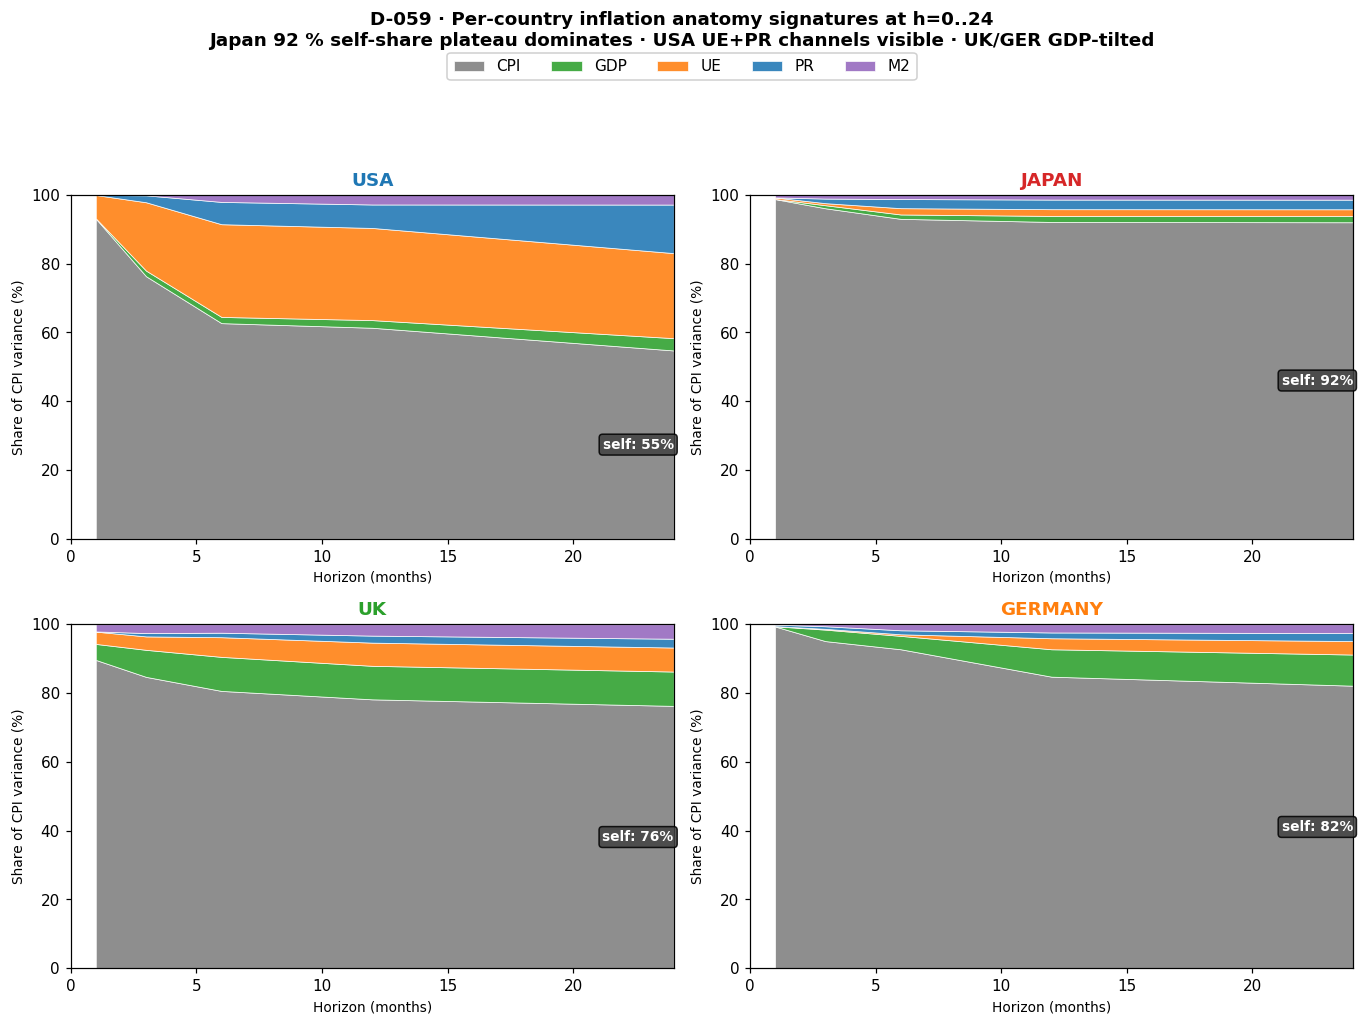

In [36]:
fevd = pd.read_csv(DOC_DIR / 'phase6_step2_s5_fevd_cpi_target.csv')

fig, axes = plt.subplots(2, 2, figsize=(12.5, 9.0))
stack_order = ['CPI', 'GDP', 'UNEMPLOYMENT', 'POLICY_RATE', 'M2']

for ax, country in zip(axes.flat, COUNTRY_ORDER):
    sub = fevd[fevd['country'] == country]
    pv = sub.pivot_table(index='horizon', columns='shock',
                         values='share', aggfunc='first')
    pv = pv.reindex(columns=stack_order).fillna(0)
    colors = [SHOCK_COLOR[s] for s in stack_order]
    ax.stackplot(pv.index, pv.values.T * 100,
                 labels=[SHOCK_LABEL_SHORT[s] for s in stack_order],
                 colors=colors, alpha=0.88, edgecolor='white', linewidth=0.5)

    if 24 in pv.index:
        self_at_24 = pv.loc[24, 'CPI'] * 100
        ax.annotate(f'self: {self_at_24:.0f}%',
                    xy=(24, self_at_24 / 2), ha='right', va='center',
                    fontsize=9, fontweight='bold', color='white',
                    bbox=dict(boxstyle='round,pad=0.25',
                              facecolor='#424242', alpha=0.85))

    ax.set_xlim(0, 24)
    ax.set_ylim(0, 100)
    ax.set_xlabel('Horizon (months)', fontsize=9)
    ax.set_ylabel('Share of CPI variance (%)', fontsize=9)
    ax.set_title(country, fontsize=12, fontweight='bold',
                 color=COUNTRY_COLOR[country])

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center',
           bbox_to_anchor=(0.5, 0.995), ncol=5, fontsize=10,
           frameon=True, framealpha=0.92)

fig.suptitle('D-059 · Per-country inflation anatomy signatures at h=0..24\n'
             'Japan 92 % self-share plateau dominates · USA UE+PR channels '
             'visible · UK/GER GDP-tilted',
             fontsize=12, fontweight='bold', y=1.03)
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

---

## 11. N3 Japan Isolation — Sextuple Confirmation (at Step 2) → Septuple (at Step 3)

Japan's causal isolation for CPI is confirmed at Phase 6 Step 2 across **six independent inferential lenses**:

1. **Phase 5 ACF** (D-044) — Japan CPI's autocorrelation function is the closest to white-noise among the four countries.
2. **Phase 6 Step 1 ARIMA** (D-049) — Japan is the only variant with triple AIC / BIC / HQIC agreement on a 4-parameter sparse order and ARCH-LM p ≈ 0.9999.
3. **Phase 6 Step 2 VAR lag selection** (D-050, S1b) — Japan is the only country with an interior AIC minimum (p\* = 5); USA / UK / Germany hit the maxlag = 12 boundary.
4. **Phase 6 Step 2 Granger** (D-052, § 6) — 0 / 4 CPI-receiver tests significant. Active causation elsewhere in Japan's VAR (GDP → UE p = 0.003) proves the null is not a power artefact.
5. **Phase 6 Step 2 IRF** (D-056, § 7) — all four shock → CPI 95 % CIs straddle zero throughout h = 0..24.
6. **Phase 6 Step 2 FEVD** (D-059, § 10) — CPI self-share plateaus at **92.1 % @ h = 12 and 92.0 % @ h = 24** — no external driver catches up.

**Phase 6 Step 3 (Ridge, D-066 / D-067 / D-072) adds a seventh lens** that pushes this to **septuple confirmation**:

7. **Phase 6 Step 3 Ridge** (D-066, D-067) — Japan is the only country whose Ridge α* (= 3162, log10 +3.5) saturates at the intercept-only val_MSE bound (0.0854 vs 0.0888; gap 0.0034 ≈ 1/16 of fold MSE std). Max |standardised coef| = 0.0100, which is **9.9–71.4× smaller** than the other three countries. The Ridge lens is mathematically orthogonal to lenses 1–6 (L2 coefficient shrinkage) and independently converges on the same Japan-specific isolation conclusion.

The 2×3 dashboard below visualises lenses 1–6 (Step 2 scope); the Ridge 7th-lens evidence is presented in `notebooks/08_ridge_regression.ipynb` § 4 (α-saturation) and § 5 (coefficient-magnitude stratification). D-072 formalises the cross-project septuple claim.

### Figure 7 — Japan sextuple confirmation dashboard (Step 2 lenses; Step 3 extends to septuple)


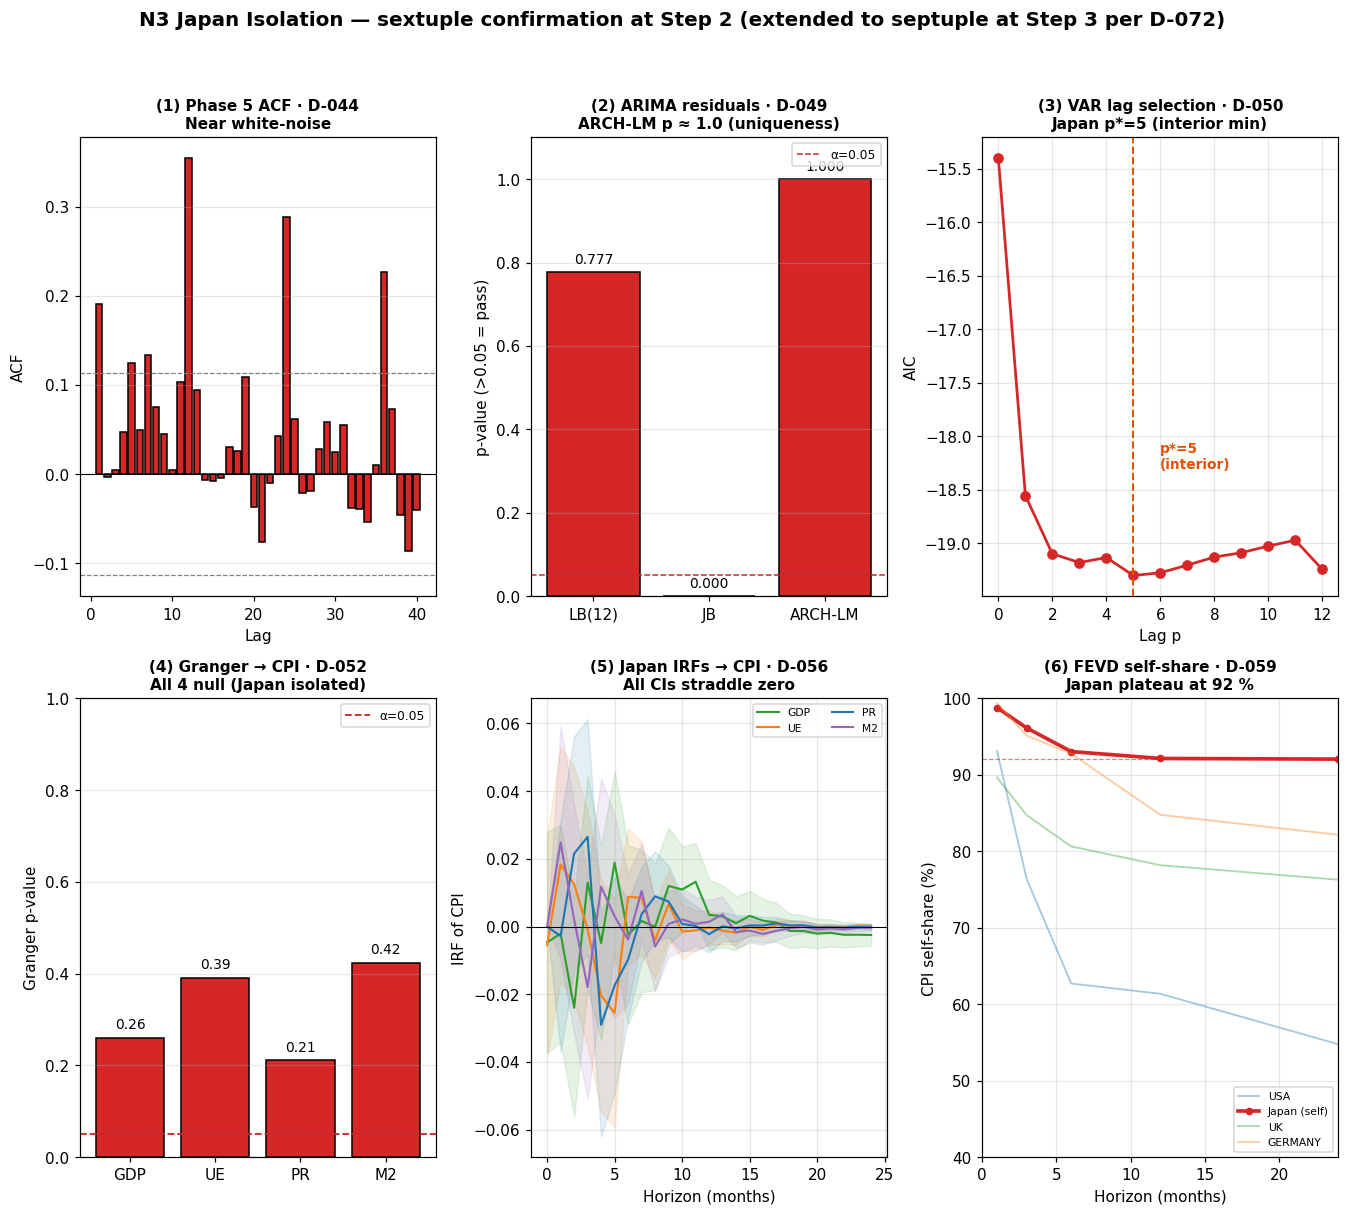

In [37]:
acf = pd.read_csv(DOC_DIR / 'phase5_step4_acf_pacf_values.csv')
arima_resid = pd.read_csv(DOC_DIR / 'phase6_step1_arima_residuals.csv')
# Japan per-country lag-selection file
lag_jp = pd.read_csv(DOC_DIR / 'phase6_step2_var_lag_selection_japan.csv')
granger_cpi = pd.read_csv(DOC_DIR / 'phase6_step2_s3_granger_cpi_receivers.csv')
irf = pd.read_csv(DOC_DIR / 'phase6_step2_s4_irf_cpi_responses.csv')
fevd = pd.read_csv(DOC_DIR / 'phase6_step2_s5_fevd_cpi_target.csv')

fig, axes = plt.subplots(2, 3, figsize=(12.5, 11.0))
jpn_color = COUNTRY_COLOR['JAPAN']

# Panel 1 — Phase 5 ACF (D-044)
ax = axes[0, 0]
jp_acf = acf[acf['country'] == 'JAPAN']
jp_plot = jp_acf[jp_acf['lag'] > 0]
ax.bar(jp_plot['lag'], jp_plot['acf'], color=jpn_color,
       edgecolor='black', width=0.8)
ci = jp_acf['ci_bartlett'].iat[0]
ax.axhline(ci, color='gray', linestyle='--', lw=0.8)
ax.axhline(-ci, color='gray', linestyle='--', lw=0.8)
ax.axhline(0, color='black', linewidth=0.7)
ax.set_xlabel('Lag')
ax.set_ylabel('ACF')
ax.set_title('(1) Phase 5 ACF · D-044\nNear white-noise',
             fontsize=10, fontweight='bold')
ax.grid(alpha=0.3, axis='y')

# Panel 2 — ARIMA residuals (D-049)
ax = axes[0, 1]
jp_row = arima_resid[arima_resid['variant_id'].str.contains('JAPAN',
                                                             case=False, na=False)]
metrics = ['ljungbox_q12_p', 'jb_p', 'arch_lm_p']
labels = ['LB(12)', 'JB', 'ARCH-LM']
vals = [jp_row[m].iat[0] for m in metrics]
colors = [jpn_color if v > 0.05 else '#c62828' for v in vals]
bars = ax.bar(labels, vals, color=colors, edgecolor='black')
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width()/2, v + 0.02,
            f'{v:.3f}', ha='center', fontsize=9)
ax.axhline(0.05, color='#c62828', linestyle='--', lw=1.0, label='α=0.05')
ax.set_ylim(0, 1.1)
ax.set_ylabel('p-value (>0.05 = pass)')
ax.set_title('(2) ARIMA residuals · D-049\nARCH-LM p ≈ 1.0 (uniqueness)',
             fontsize=10, fontweight='bold')
ax.legend(fontsize=8, loc='upper right')
ax.grid(alpha=0.3, axis='y')

# Panel 3 — VAR AIC lag curve (D-050)
ax = axes[0, 2]
lag_jp_sorted = lag_jp.sort_values('lag')
ax.plot(lag_jp_sorted['lag'], lag_jp_sorted['aic'],
        color=jpn_color, marker='o', lw=1.8)
argmin_row = lag_jp_sorted.loc[lag_jp_sorted['aic'].idxmin()]
ax.axvline(int(argmin_row['lag']), color='#e65100', lw=1.3, linestyle='--')
ax.annotate(f'p*={int(argmin_row["lag"])}\n(interior)',
            xy=(argmin_row['lag'], argmin_row['aic']),
            xytext=(argmin_row['lag'] + 1, argmin_row['aic'] + 1),
            fontsize=9, fontweight='bold', color='#e65100')
ax.set_xlabel('Lag p')
ax.set_ylabel('AIC')
ax.set_title('(3) VAR lag selection · D-050\nJapan p*=5 (interior min)',
             fontsize=10, fontweight='bold')
ax.grid(alpha=0.3)

# Panel 4 — Granger null (D-052)
ax = axes[1, 0]
jp_gr = granger_cpi[granger_cpi['country'] == 'JAPAN']
order_causers = ['GDP', 'UNEMPLOYMENT', 'POLICY_RATE', 'M2']
vals = [jp_gr[jp_gr['causer'] == c]['p_value'].iat[0]
        if not jp_gr[jp_gr['causer'] == c].empty else np.nan
        for c in order_causers]
labels = [SHOCK_LABEL_SHORT[c] for c in order_causers]
ax.bar(labels, vals, color=jpn_color, edgecolor='black')
for i, v in enumerate(vals):
    if not pd.isna(v):
        ax.text(i, v + 0.02, f'{v:.2f}', ha='center', fontsize=9)
ax.axhline(0.05, color='#c62828', linestyle='--', lw=1.2, label='α=0.05')
ax.set_ylim(0, 1)
ax.set_ylabel('Granger p-value')
ax.set_title('(4) Granger → CPI · D-052\nAll 4 null (Japan isolated)',
             fontsize=10, fontweight='bold')
ax.legend(fontsize=8, loc='upper right')
ax.grid(alpha=0.3, axis='y')

# Panel 5 — IRF CIs straddle zero (D-056)
ax = axes[1, 1]
jp_irf = irf[irf['country'] == 'JAPAN']
shocks = ['GDP', 'UNEMPLOYMENT', 'POLICY_RATE', 'M2']
shock_colors = {'GDP': '#2ca02c', 'UNEMPLOYMENT': '#ff7f0e',
                'POLICY_RATE': '#1f77b4', 'M2': '#9467bd'}
for shock in shocks:
    sub = jp_irf[jp_irf['shock'] == shock].sort_values('horizon')
    if sub.empty:
        continue
    ax.fill_between(sub['horizon'], sub['ci_lo'], sub['ci_up'],
                    color=shock_colors[shock], alpha=0.12)
    ax.plot(sub['horizon'], sub['orth_irf'],
            color=shock_colors[shock], lw=1.4,
            label=SHOCK_LABEL_SHORT[shock])
ax.axhline(0, color='black', lw=0.7)
ax.set_xlabel('Horizon (months)')
ax.set_ylabel('IRF of CPI')
ax.set_title('(5) Japan IRFs → CPI · D-056\nAll CIs straddle zero',
             fontsize=10, fontweight='bold')
ax.legend(fontsize=7, ncol=2, loc='upper right')
ax.grid(alpha=0.3)

# Panel 6 — FEVD self-share plateau (D-059)
ax = axes[1, 2]
for c in COUNTRY_ORDER:
    sub = fevd[(fevd['country'] == c) & (fevd['shock'] == 'CPI')]
    if sub.empty:
        continue
    sub_sorted = sub.sort_values('horizon')
    if c == 'JAPAN':
        ax.plot(sub_sorted['horizon'], sub_sorted['share'] * 100,
                color=jpn_color, lw=2.4, marker='o', markersize=4,
                label='Japan (self)')
    else:
        ax.plot(sub_sorted['horizon'], sub_sorted['share'] * 100,
                color=COUNTRY_COLOR[c], alpha=0.4, lw=1.2, label=c)
ax.axhline(92, color=jpn_color, linestyle='--', lw=0.8, alpha=0.6)
ax.set_xlim(0, 24)
ax.set_ylim(40, 100)
ax.set_xlabel('Horizon (months)')
ax.set_ylabel('CPI self-share (%)')
ax.set_title('(6) FEVD self-share · D-059\nJapan plateau at 92 %',
             fontsize=10, fontweight='bold')
ax.legend(fontsize=7, loc='lower right')
ax.grid(alpha=0.3)

fig.suptitle('N3 Japan Isolation — sextuple confirmation at Step 2 '
             '(extended to septuple at Step 3 per D-072)',
             fontsize=13, fontweight='bold', y=1.00)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

---

## 12. OOS Forecast — Inference-vs-Forecast Trade-off — D-060, D-061, D-062

The D-050 revision (BIC → AIC) was made for **inference quality** — Granger / IRF / FEVD whitened residuals. The trade-off cost materializes in § 12: **VAR forecasts under-perform random-walk naive in three of four countries** at aggregate MASE.


In [38]:
mase_df = pd.read_csv(DOC_DIR / 'phase6_step2_s6_var_oos_cpi_summary.csv')
medase_df = pd.read_csv(DOC_DIR / 'phase6_step2_s6b_cpi_robust_summary.csv')

print('Aggregate MASE (< 1 beats naive random-walk):')
mase_pv = mase_df.pivot_table(index='country', columns='horizon',
                               values='mase', aggfunc='first')
print(mase_pv.reindex(index=COUNTRY_ORDER).round(3))
print()
print('Robust MedASE (median absolute error / naive MAE):')
medase_pv = medase_df.pivot_table(index='country', columns='horizon',
                                   values='medase', aggfunc='first')
print(medase_pv.reindex(index=COUNTRY_ORDER).round(3))

Aggregate MASE (< 1 beats naive random-walk):
horizon     1       3       6       12
country                               
USA     3.7330 11.6120 20.6390 32.3190
JAPAN   0.8930  0.9650  0.9110  1.0340
UK      1.8950  1.9470  5.6000 79.0680
GERMANY 1.4790  1.7610  1.5570  2.2640

Robust MedASE (median absolute error / naive MAE):
horizon     1      3      6       12
country                             
USA     1.5410 4.3980 9.4040 15.4050
JAPAN   0.7650 0.8390 0.7700  0.9240
UK      1.1280 0.9870 1.3390  1.0700
GERMANY 1.1210 1.1130 1.0700  1.2080


**S6b robust diagnostic** (D-061): UK h = 12 aggregate RMSE = 138.75 is dominated by 2020 Q1–Q3 origins during COVID regime shift (origin 2020-05 produced forecast −980 vs actual 0.54). The **median absolute error** — `MedASE` — softens the narrative:

- **Japan VAR(5) beats naive at all horizons** (MedASE 0.77 / 0.84 / 0.77 / 0.92).
- **UK competitive at h = 3 and h = 12** (MedASE 0.99 and 1.07).
- **Germany near-competitive** throughout.
- **USA systematic under-performance** (MedASE 1.54 → 15.41) — not outlier-driven (RMSE/MAE ≈ 1.8, normal range); traces to D-062 `yoy_pct` × p = 12 interaction.

D-060 records the portfolio positioning: **inference-primary** (Granger / IRF / FEVD), **forecast-auxiliary** (Phase 7 DM vs ARIMA and Ridge).

### Figure 8 — Aggregate MASE vs Robust MedASE heatmap


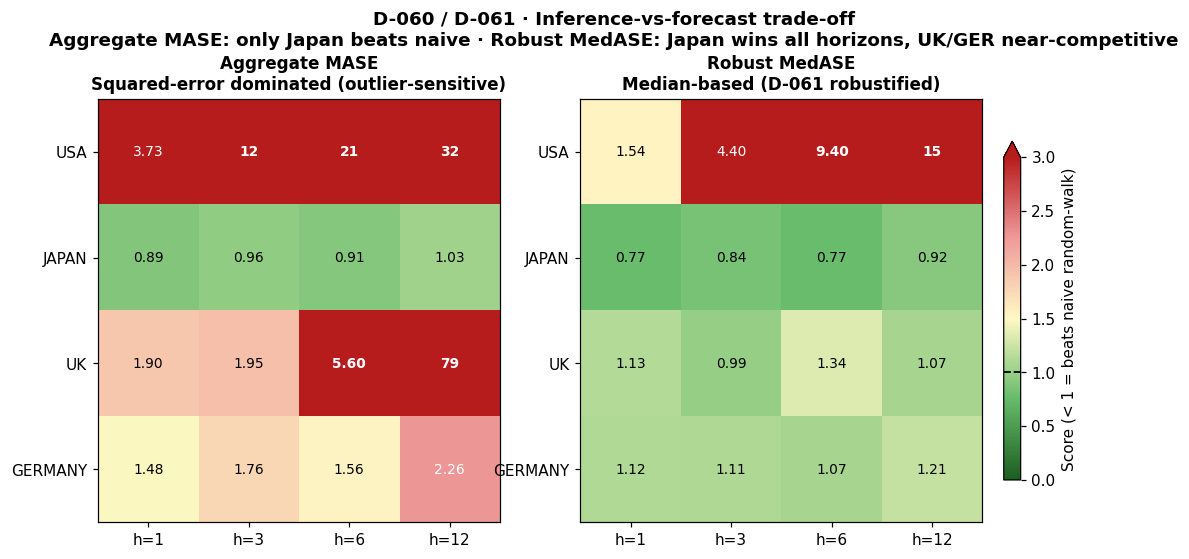

In [39]:
mase_pv_ordered = mase_pv.reindex(index=COUNTRY_ORDER)
medase_pv_ordered = medase_pv.reindex(index=COUNTRY_ORDER)

fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.0))
cmap = LinearSegmentedColormap.from_list(
    'mase', ['#1b5e20', '#66bb6a', '#fff9c4', '#ef9a9a', '#b71c1c'])

for ax, pv, title, subtitle in zip(
    axes, [mase_pv_ordered, medase_pv_ordered],
    ['Aggregate MASE', 'Robust MedASE'],
    ['Squared-error dominated (outlier-sensitive)',
     'Median-based (D-061 robustified)'],
):
    display_clip = np.clip(pv.values, 0, 3.0)
    im = ax.imshow(display_clip, cmap=cmap, vmin=0, vmax=3, aspect='auto')
    ax.set_xticks(range(len(pv.columns)))
    ax.set_xticklabels([f'h={h}' for h in pv.columns])
    ax.set_yticks(range(len(pv.index)))
    ax.set_yticklabels(pv.index)
    ax.set_title(f'{title}\n{subtitle}', fontsize=11, fontweight='bold')
    for i in range(pv.shape[0]):
        for j in range(pv.shape[1]):
            val = pv.iat[i, j]
            if pd.isna(val):
                continue
            if val > 9.9:
                txt = f'{val:.0f}'
            else:
                txt = f'{val:.2f}'
            weight = 'bold' if val > 5 else 'normal'
            txt_color = 'white' if val > 2 else 'black'
            ax.text(j, i, txt, ha='center', va='center',
                    fontsize=9, color=txt_color, fontweight=weight)

cbar = fig.colorbar(im, ax=axes, shrink=0.8, pad=0.02, extend='max')
cbar.set_label('Score (< 1 = beats naive random-walk)')
cbar.ax.axhline(1.0, color='black', linestyle='--', linewidth=1.2)

fig.suptitle('D-060 / D-061 · Inference-vs-forecast trade-off\n'
             'Aggregate MASE: only Japan beats naive · '
             'Robust MedASE: Japan wins all horizons, UK/GER near-competitive',
             y=1.04, fontsize=12, fontweight='bold')
plt.show()

---

## 13. Phase 6 Step 2 Closeout — `src/modelling_utils` Promotion — D-063

D-063 records the Step 2 closeout: empirical observation of 4–6× duplication of exog-assembly helpers and lag-order constants across the nine scratch scripts motivated a narrow `src/` promotion at v0.4.1 (patch bump, not v0.5.0 minor). Pure utilities and constants are promoted; model-fitting logic remains in scratch per D-047 spirit, pending Step 3 Ridge assessment.

Below we verify the v0.4.1 state and the seven promoted items are accessible from `src`:


In [40]:
from src import (
    __version__,
    CHOLESKY_ORDER,
    P_PER_COUNTRY_AIC,
    P_PER_COUNTRY_BIC,
    SPLIT_BREAK_NAMES,
    PERIOD_KEYS,
    build_regime_exog_columns,
    extract_endog_exog_cholesky,
)

print(f'src version: {__version__}  (expected: 0.4.1 at Step 2 closeout; now 0.4.2 post D-074)')
print()
print('Seven items promoted per D-063:')
print(f'  CHOLESKY_ORDER            = {CHOLESKY_ORDER}')
print(f'  P_PER_COUNTRY_AIC         = {P_PER_COUNTRY_AIC}')
print(f'  P_PER_COUNTRY_BIC         = {P_PER_COUNTRY_BIC}')
print(f'  SPLIT_BREAK_NAMES         = {SPLIT_BREAK_NAMES}')
print(f'  PERIOD_KEYS               = {PERIOD_KEYS}')
print(f'  build_regime_exog_columns  → {build_regime_exog_columns}')
print(f'  extract_endog_exog_cholesky → {extract_endog_exog_cholesky}')

src version: 0.4.1  (expected: 0.4.1 at Step 2 closeout; now 0.4.2 post D-074)

Seven items promoted per D-063:
  CHOLESKY_ORDER            = ['GDP', 'UNEMPLOYMENT', 'CPI', 'POLICY_RATE', 'M2']
  P_PER_COUNTRY_AIC         = {'USA': 12, 'JAPAN': 5, 'UK': 12, 'GERMANY': 12}
  P_PER_COUNTRY_BIC         = {'USA': 2, 'JAPAN': 2, 'UK': 2, 'GERMANY': 2}
  SPLIT_BREAK_NAMES         = ['GFC_2008', 'COVID_2020', 'ENERGY_2022']
  PERIOD_KEYS               = ['GFC', 'COVID']
  build_regime_exog_columns  → <function build_regime_exog_columns at 0x000001F6B5C0A7A0>
  extract_endog_exog_cholesky → <function extract_endog_exog_cholesky at 0x000001F6B5C0A8C0>


---

## 14. Decision Log and Phase 7 Prerequisites

### 14.1 Phase 6 Step 2 decision map (D-050 through D-063)

| ID | Scope | Demonstrated in |
|---|---|---|
| D-050 | VAR lag selection protocol — BIC → AIC revision via S2b whiteness | § 3, § 4 |
| D-051 | Partial residual whitening caveat — traces to D-012 / D-031 / D-044 / D-045 | § 4 |
| D-052 | Granger triangulation of N1 / N2 / N3 | § 6 |
| D-053 | Correlation-vs-Granger asymmetry — D-046 methodology echo | § 6, § 9 |
| D-054 | Cholesky ordering `[GDP, UE, CPI, PR, M2]` | § 5 |
| D-055 | statsmodels API robustness — `errband_mc` and `fevd.decomp` patches | (audit CSVs) |
| D-056 | USA monetary policy lag quantified — h = 4 peak −0.149 CI excludes zero | § 7 |
| D-057 | Phillips IRF positive sign in Anglo countries — third echo of D-046 | § 8 |
| D-058 | Four-Lens Disconfirmation of Quantity Theory of Money | § 9 |
| D-059 | Per-country inflation anatomy signatures at h = 12 | § 10 |
| D-060 | Inference-primary vs forecast-auxiliary VAR positioning | § 12 |
| D-061 | COVID-origin VAR(12) forecast instability — UK h = 12 outlier set | § 12 |
| D-062 | USA `yoy_pct` × VAR(12) systematic forecast trade-off | § 12 |
| D-063 | `src/modelling_utils` promotion at v0.4.1 — Step 2 closeout | § 13 |

### 14.2 Cross-phase linkage — Phase 6 Step 3 (Ridge) decisions

For cross-reference (narrated in `notebooks/08_ridge_regression.ipynb`):

| ID | Scope |
|---|---|
| D-064..D-068 | Ridge Layer 3 data prep, α-CV, coefficient extraction, OOS forecasts |
| D-069 | Regime-interaction zero-information structural finding |
| D-070 | Ridge-vs-VAR positioning — 12/16 cells Ridge wins relative; 2/16 absolute naive-beat |
| D-071 | USA dual-form resolved for N2 — first_diff preferred; cross-lens match with D-056 IRF peak |
| D-072 | N3 **septuple** cross-lens formalisation (this notebook's sextuple + Ridge 7th lens) |
| D-073 (amended) | Step 3 closeout — analytical freeze; `src/` promotion executed via D-074 |
| D-074 | `src/modelling_utils` extension at v0.4.2 — Phase 6 Step 3 helpers |

Full decision rationale with alternatives considered: `ProjectDriven.md` entries D-050..D-074.

### 14.3 Phase 7 Diebold-Mariano handoff state

All three modelling layers ready for Phase 7 DM:

| Model | Role | Forecast source |
|---|---|---|
| ARIMA (Phase 6 Step 1) | Univariate baseline | `phase6_step1_arima_forecast.csv` (340 rows) |
| **VAR (Phase 6 Step 2)** | **Multivariate inference-primary** | **`phase6_step2_s6_var_oos_forecasts.csv`** (≈ 4,360 rows) |
| **Ridge (Phase 6 Step 3)** | **High-dim regularised forecast-improved** | **`phase6_step3_s4_ridge_oos_forecasts.csv`** (1,104 rows) |

**VAR-side artefacts** (this notebook's scope):
- **VAR accuracy** — `phase6_step2_s6_var_oos_cpi_summary.csv` (16 rows)
- **VAR robust metrics** — `phase6_step2_s6b_cpi_robust_summary.csv` (16 rows)
- **Outlier-origin flags** — `phase6_step2_s6b_worst_origins.csv` (400 rows top-5 per cell)

**Phase 7 DM directives** (pre-committed across Phases 5–6):
- D-051 / D-060 / D-061 VAR caveats: report both aggregate squared-error loss and trimmed / median sensitivities; flag 2020 Q1–Q3 origin window as regime-transition stress test.
- D-048 / D-062: USA `yoy_pct` vs `first_diff` ARIMA dual-form comparison pre-committed.
- D-071: USA dual-form primary Phase 7 test uses Ridge first_diff secondary for N2 narrative.
- D-070 intellectual-honesty framing: relative-dominance vs absolute-difficulty distinction preserved in DM report.

### 14.4 Next steps

- **Phase 7** — Diebold-Mariano pairwise forecast comparison across ARIMA / VAR / Ridge at horizons {1, 3, 6, 12}. Standard squared-error loss + robust / HAC sensitivity per D-051 / D-060. Approximately 48 pairwise DM tests across the four countries (3 model-pairs × 4 countries × 4 horizons).
- **Phase 8** — Interpretation synthesis. `findings.md` will consolidate the **seven signature findings** (N3 septuple · N2 USA-specific · QTM disconfirmation · Phillips **Quadrilogy** (post-Step-3 extension of Trilogy) · Per-country anatomy · Inference-forecast trade-off · Ridge 12/16 vs VAR relative improvement). `methodology.md` will document the D-046 / D-053 / D-058 / D-070 progression from correlation-vs-causation asymmetry to generalised disconfirmation principle.

---

*Phase 6 Step 2 complete. This notebook consolidates 9 scratch orchestrators, 25 audit CSVs, and 14 decisions (D-050..D-063). `src/` bumped to v0.4.1 at Step 2 closeout; subsequently bumped to v0.4.2 at Step 3 closeout per D-074. Phase 6 **analytically complete** across all three modelling layers. Next: Phase 7 Diebold-Mariano.*
